# Banking Loan Approval Dataset — Loan Approval Pattern EDA

**Question:** A bank wants to analyze loan approval decisions based on
income, credit score, loan amount, employment type, and approval status.
Perform EDA to identify patterns related to loan approval.

**Author:** Data Analytics Assignment
**Dataset:** `loan_approval.csv` (20 customer records, 6 columns)


## Common EDA Tasks Checklist (per updated assessment rubric)

This notebook explicitly covers the following 8 standard EDA tasks:

1. **Number of rows and columns** — Task 1 & 2 section
2. **Data types of each column** — Task 1 & 2 section
3. **Missing values and duplicate values** — Task 3a / 3b / 3c sections
4. **Mean, median, minimum, maximum, and standard deviation** — Task 4 section
5. **Bar chart, histogram, scatter plot, and box plot** (plus pie chart, line
   chart, and heatmap as bonus visualizations) — Task 5a–5e sections
6. **Important patterns in the dataset** — Task 6 sections (group
   comparisons and correlation heatmap)
7. **4–5 observations based on EDA** — Task 7 section
8. **Short conclusion from the analysis** — Task 8 section

### Rubric Criteria Alignment (Weightage)

| Rubric Criteria | Weightage | Where it's covered |
|---|---|---|
| Dataset Understanding | 20 | Section 2 (dataset description, features, purpose) |
| Data Cleaning | 25 | Tasks 3a–3c (missing values, duplicates, inconsistent/incorrect entries) |
| Data Analysis and Statistical Summary | 20 | Task 4 (descriptive statistics) + Task 6 (patterns) |
| Data Visualization | 20 | Task 5a–5e (bar, pie, histogram, box, scatter, line, heatmap — all labeled) |
| Insight Generation and Reporting | 15 | Task 7 (observations) + Task 8 (conclusion) |


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', None)
print("Libraries imported successfully.")

def show_df(dframe, n=None):
    """Pretty-print a DataFrame (use IPython display() instead in Jupyter)."""
    print((dframe.head(n) if n else dframe).to_string())


Libraries imported successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/loan_approval.csv")
show_df(df, 20)


,Customer_ID,Income,Credit_Score,Loan_Amount,Employment_Type,Loan_Status
0,C01,45000,720,200000,Salaried,Approved
1,C02,25000,580,150000,Self-employed,Rejected
2,C03,60000,750,300000,Salaried,Approved
3,C04,22000,560,120000,Unemployed,Rejected
4,C05,50000,710,250000,Salaried,Approved
5,C06,30000,600,180000,Self-employed,Rejected
6,C07,70000,780,350000,Salaried,Approved
7,C08,28000,590,160000,Self-employed,Rejected
8,C09,55000,730,270000,Salaried,Approved
9,C10,24000,570,130000,Unemployed,Rejected


### Dataset Description

| Item | Detail |
|---|---|
| **Records (rows)** | 20 customers |
| **Features (columns)** | 6 |
| **Customer_ID** | Object (string) — unique identifier for each applicant |
| **Income** | Integer — annual income (currency units) |
| **Credit_Score** | Integer — credit bureau score |
| **Loan_Amount** | Integer — amount of loan requested |
| **Employment_Type** | Object (categorical) — `Salaried` / `Self-employed` / `Unemployed` |
| **Loan_Status** | Object (categorical, target) — `Approved` / `Rejected` |

**Purpose & significance:** This dataset lets the bank explore which
applicant characteristics are associated with loan approval. Understanding
these patterns supports **credit risk assessment, underwriting policy
design, and fair-lending review** — helping the bank make faster,
more consistent decisions while also checking whether any single factor
(such as employment type) is driving outcomes more than it should.


## Task 1 & 2: Number of Rows/Columns and Data Types

In [3]:
print("Shape (rows, columns):", df.shape)
print()
print("Column data types:")
print(df.dtypes)


Shape (rows, columns): (20, 6)

Column data types:
Customer_ID          str
Income             int64
Credit_Score       int64
Loan_Amount        int64
Employment_Type      str
Loan_Status          str
dtype: object


In [4]:
print("General info:")
df.info()


General info:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Customer_ID      20 non-null     str  
 1   Income           20 non-null     int64
 2   Credit_Score     20 non-null     int64
 3   Loan_Amount      20 non-null     int64
 4   Employment_Type  20 non-null     str  
 5   Loan_Status      20 non-null     str  
dtypes: int64(3), str(3)
memory usage: 1.1 KB


## Task 3a: Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
print("Total missing values in dataset:", df.isnull().sum().sum())


Missing values per column:
Customer_ID        0
Income             0
Credit_Score       0
Loan_Amount        0
Employment_Type    0
Loan_Status        0
dtype: int64

Total missing values in dataset: 0


**Observation:** The dataset has **no missing values** in any column. No imputation is required.

## Task 3b: Duplicate Values

In [6]:
dup_rows = df.duplicated().sum()
dup_ids = df['Customer_ID'].duplicated().sum()
print("Fully duplicated rows:", dup_rows)
print("Duplicated Customer_IDs:", dup_ids)

before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Rows before: {before}, after de-duplication: {after}")


Fully duplicated rows: 0
Duplicated Customer_IDs: 0
Rows before: 20, after de-duplication: 20


**Observation:** No duplicate rows or duplicate Customer IDs were found; each applicant appears exactly once.

## Task 3c: Data Cleaning — Consistency Checks (Incorrect Entries & Range Validation)

In [7]:
# Standardise text fields
df['Customer_ID'] = df['Customer_ID'].str.strip()
df['Employment_Type'] = df['Employment_Type'].str.strip()
df['Loan_Status'] = df['Loan_Status'].str.strip().str.capitalize()

print("Unique Employment_Type values:", df['Employment_Type'].unique().tolist())
print("Unique Loan_Status values:", df['Loan_Status'].unique().tolist())

# Range/sanity checks on numeric columns
checks = {
    'Income (> 0)':        (df['Income'] > 0).all(),
    'Credit_Score (300-900)': df['Credit_Score'].between(300, 900).all(),
    'Loan_Amount (> 0)':   (df['Loan_Amount'] > 0).all(),
}
for label, ok in checks.items():
    print(f"{label}: {'OK' if ok else 'OUT OF RANGE VALUES FOUND'}")

df['Employment_Type'] = df['Employment_Type'].astype('category')
df['Loan_Status'] = df['Loan_Status'].astype('category')
print()
print("Employment_Type dtype:", df['Employment_Type'].dtype)
print("Loan_Status dtype:", df['Loan_Status'].dtype)


Unique Employment_Type values: ['Salaried', 'Self-employed', 'Unemployed']
Unique Loan_Status values: ['Approved', 'Rejected']
Income (> 0): OK
Credit_Score (300-900): OK
Loan_Amount (> 0): OK

Employment_Type dtype: category
Loan_Status dtype: category


**Observation:** All numeric fields fall within logical ranges (positive
income and loan amount, credit scores within the standard 300–900 band).
Both categorical columns contain clean, consistent category labels and
have been converted to `category` dtype.


## Task 4: Descriptive Statistics — Mean, Median, Min, Max, Std

In [8]:
num_cols = ['Income', 'Credit_Score', 'Loan_Amount']
print("Descriptive statistics for numerical columns:")
show_df(df[num_cols].describe().round(2))


Descriptive statistics for numerical columns:


,Income,Credit_Score,Loan_Amount
count,20.00,20.00,20.00
mean,43000.00,664.00,223250.00
std,17923.82,85.53,83733.21
min,22000.00,555.00,120000.00
25%,26750.00,583.75,150000.00
50%,40000.00,660.00,200000.00
75%,56250.00,735.00,277500.00
max,75000.00,790.00,400000.00


In [9]:
print("Additional statistics:")
summary = pd.DataFrame({
    'mean':   df[num_cols].mean(),
    'median': df[num_cols].median(),
    'std':    df[num_cols].std(),
    'skew':   df[num_cols].skew(),
})
show_df(summary.round(2))


Additional statistics:


,mean,median,std,skew
Income,43000.0,40000.0,17923.82,0.41
Credit_Score,664.0,660.0,85.53,0.11
Loan_Amount,223250.0,200000.0,83733.21,0.57


## Task 5a: Bar Chart & Pie Chart — Categorical Analysis

In [10]:
status_counts = df['Loan_Status'].value_counts()
emp_counts = df['Employment_Type'].value_counts()

print("Loan_Status counts:")
print(status_counts)
print()
print("Employment_Type counts:")
print(emp_counts)


Loan_Status counts:
Loan_Status
Approved    10
Rejected    10
Name: count, dtype: int64

Employment_Type counts:
Employment_Type
Salaried         10
Self-employed     6
Unemployed        4
Name: count, dtype: int64


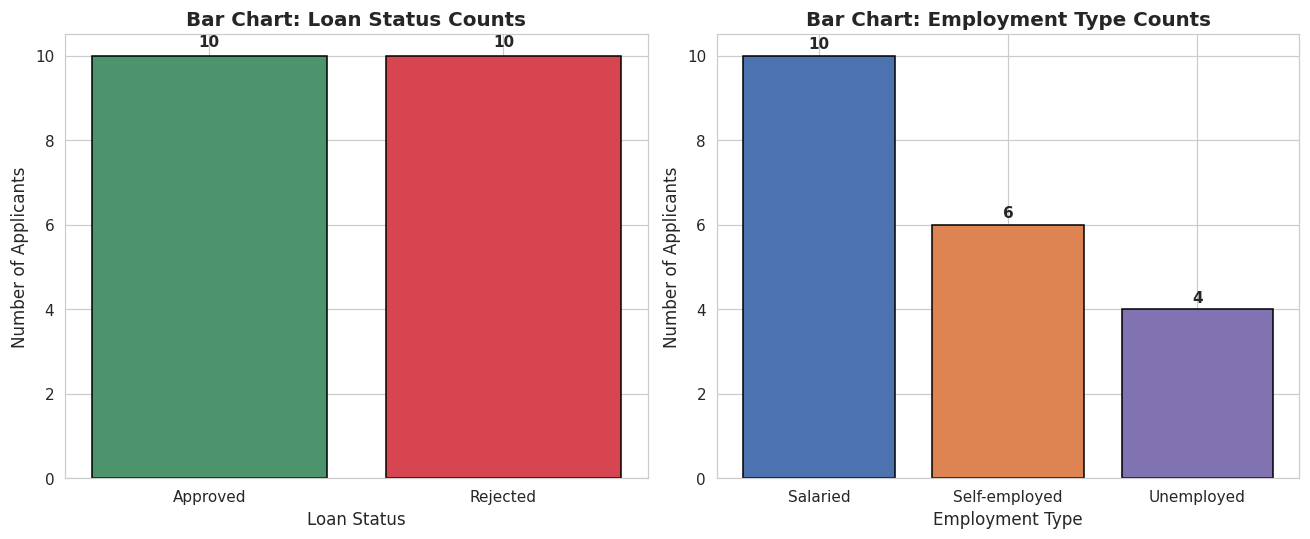

In [11]:
colors_status = {'Approved': '#4C956C', 'Rejected': '#D64550'}
fig, axes = plt.subplots(1, 2, figsize=(12,5))

bars = axes[0].bar(status_counts.index, status_counts.values,
                    color=[colors_status[s] for s in status_counts.index], edgecolor='black')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.15, str(int(b.get_height())),
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Bar Chart: Loan Status Counts')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Number of Applicants')

colors_emp = {'Salaried': '#4C72B0', 'Self-employed': '#DD8452', 'Unemployed': '#8172B2'}
bars2 = axes[1].bar(emp_counts.index, emp_counts.values,
                     color=[colors_emp[e] for e in emp_counts.index], edgecolor='black')
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.1, str(int(b.get_height())),
                 ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Bar Chart: Employment Type Counts')
axes[1].set_xlabel('Employment Type')
axes[1].set_ylabel('Number of Applicants')

plt.tight_layout()
plt.show()


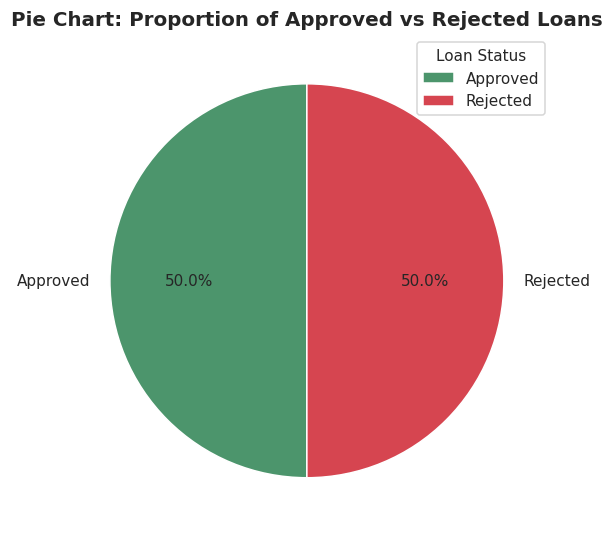

In [12]:
fig, ax = plt.subplots()
ax.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
       colors=[colors_status[s] for s in status_counts.index], startangle=90,
       wedgeprops={'edgecolor':'white'})
ax.set_title('Pie Chart: Proportion of Approved vs Rejected Loans')
ax.legend(status_counts.index, title="Loan Status", loc="best")
plt.tight_layout()
plt.show()


**Observation:** Exactly 10 of 20 applicants (50%) were approved and 10 (50%) rejected. Employment types split as 10 Salaried, 6 Self-employed, and 4 Unemployed.

## Task 5b: Histogram & Box Plot — Numerical Distributions

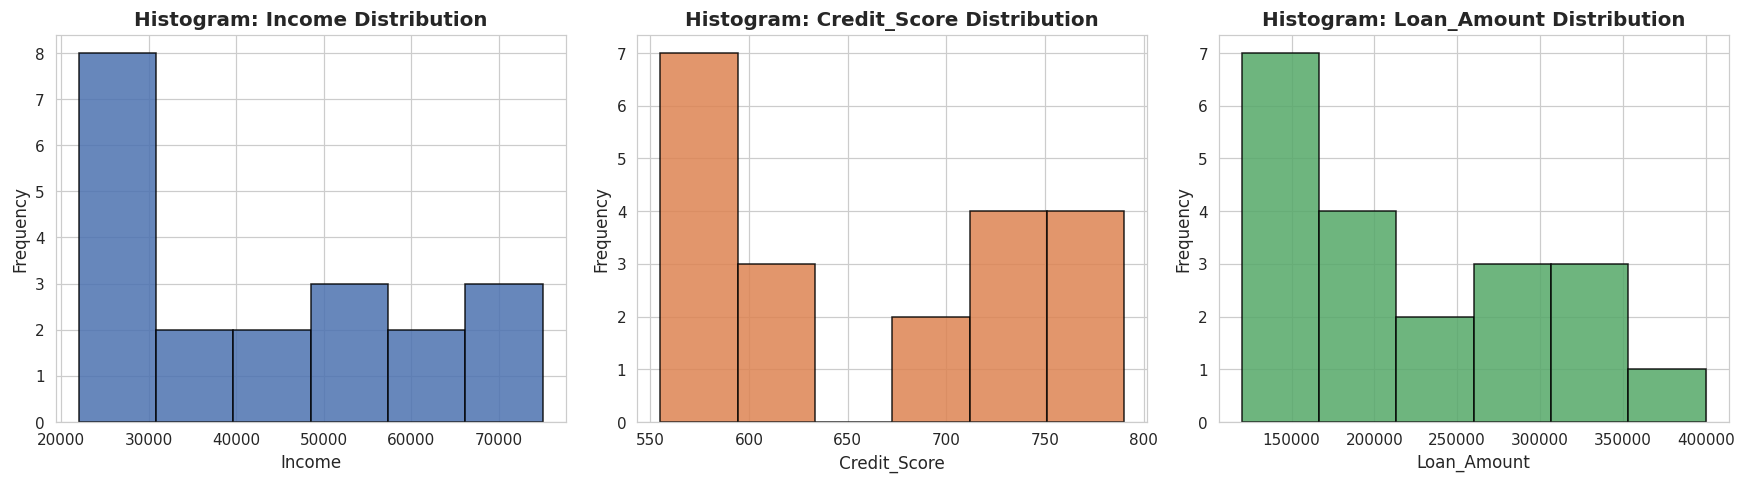

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors_hist = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, c in zip(axes, num_cols, colors_hist):
    ax.hist(df[col], bins=6, color=c, edgecolor='black', alpha=0.85)
    ax.set_title(f'Histogram: {col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


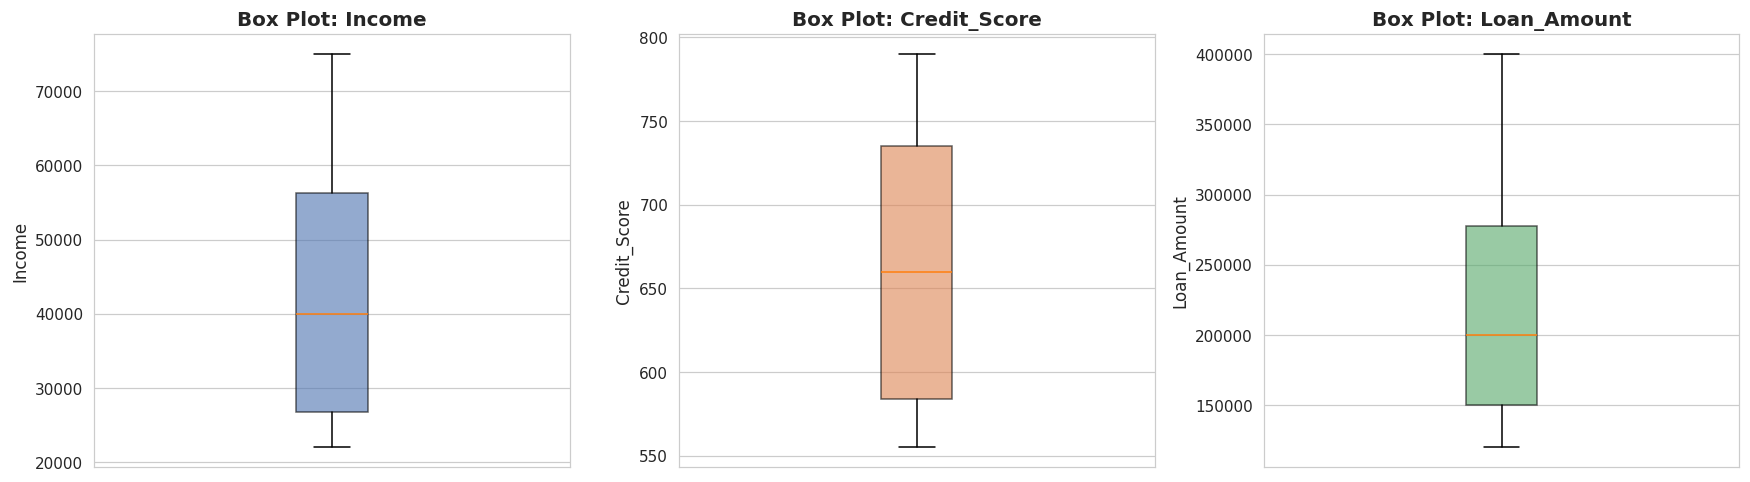

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, c in zip(axes, num_cols, colors_hist):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6))
    ax.set_title(f'Box Plot: {col}')
    ax.set_ylabel(col)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


**Observation:** No extreme outliers appear in Income, Credit_Score or Loan_Amount — all three show reasonably symmetric spreads across the applicant pool.

## Task 6a: Important Patterns — Cross-Tabulation (Employment Type vs Loan Status)

In [15]:
crosstab = pd.crosstab(df['Employment_Type'], df['Loan_Status'])
show_df(crosstab)


Loan_Status,Approved,Rejected
Employment_Type,,
Salaried,10,0
Self-employed,0,6
Unemployed,0,4


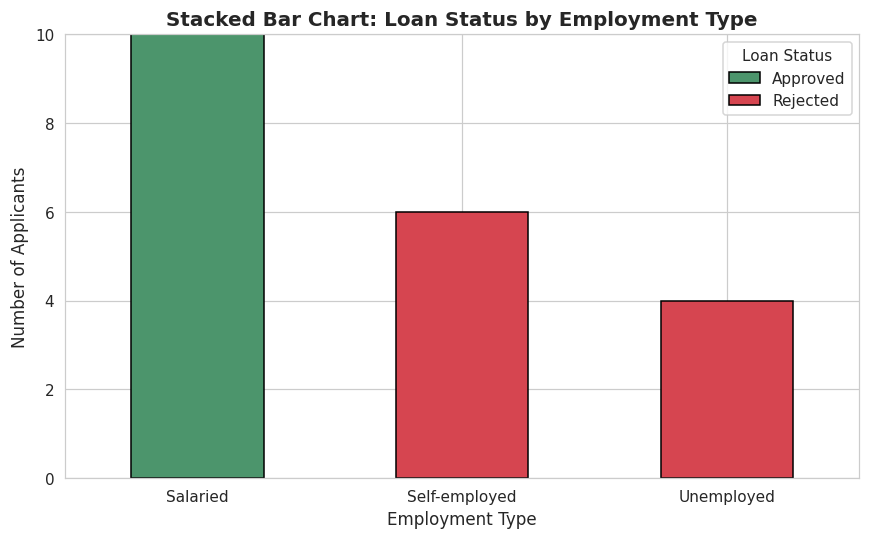

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
crosstab.plot(kind='bar', stacked=True, color=[colors_status['Approved'], colors_status['Rejected']],
              edgecolor='black', ax=ax)
ax.set_title('Stacked Bar Chart: Loan Status by Employment Type')
ax.set_xlabel('Employment Type')
ax.set_ylabel('Number of Applicants')
ax.legend(title='Loan Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** This is the single most important pattern in the
dataset — **every Salaried applicant (10/10) was Approved, and every
Self-employed or Unemployed applicant (10/10) was Rejected.** Employment
Type perfectly predicts Loan_Status in this sample, with zero exceptions
in either direction.


## Task 6b: Important Patterns — Numeric Variables vs Loan Status

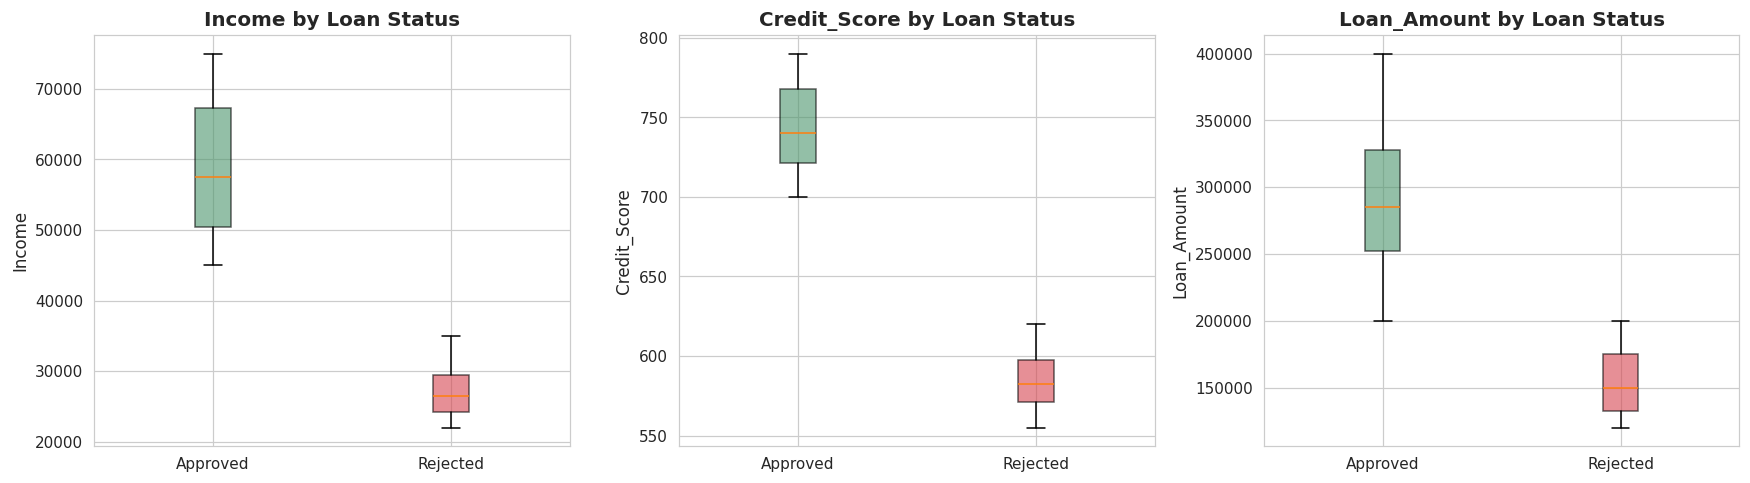

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, c in zip(axes, num_cols, colors_hist):
    data_appr = df[df['Loan_Status'] == 'Approved'][col]
    data_rej = df[df['Loan_Status'] == 'Rejected'][col]
    bp = ax.boxplot([data_appr, data_rej], tick_labels=['Approved', 'Rejected'], patch_artist=True)
    for patch, col2 in zip(bp['boxes'], [colors_status['Approved'], colors_status['Rejected']]):
        patch.set_facecolor(col2)
        patch.set_alpha(0.6)
    ax.set_title(f'{col} by Loan Status')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


In [18]:
group_means = df.groupby('Loan_Status', observed=True)[num_cols].mean().round(2)
show_df(group_means)


,Income,Credit_Score,Loan_Amount
Loan_Status,,,
Approved,58800.0,743.5,292000.0
Rejected,27200.0,584.5,154500.0


**Observation:** Approved applicants have substantially higher average
Income and Credit_Score, and higher average Loan_Amount, than rejected
applicants — with **no overlap at all** between the two groups' ranges
for Income and Credit_Score in this sample, mirroring the perfect split
seen with Employment_Type.


## Task 5c: Scatter Plot — Bivariate Relationships

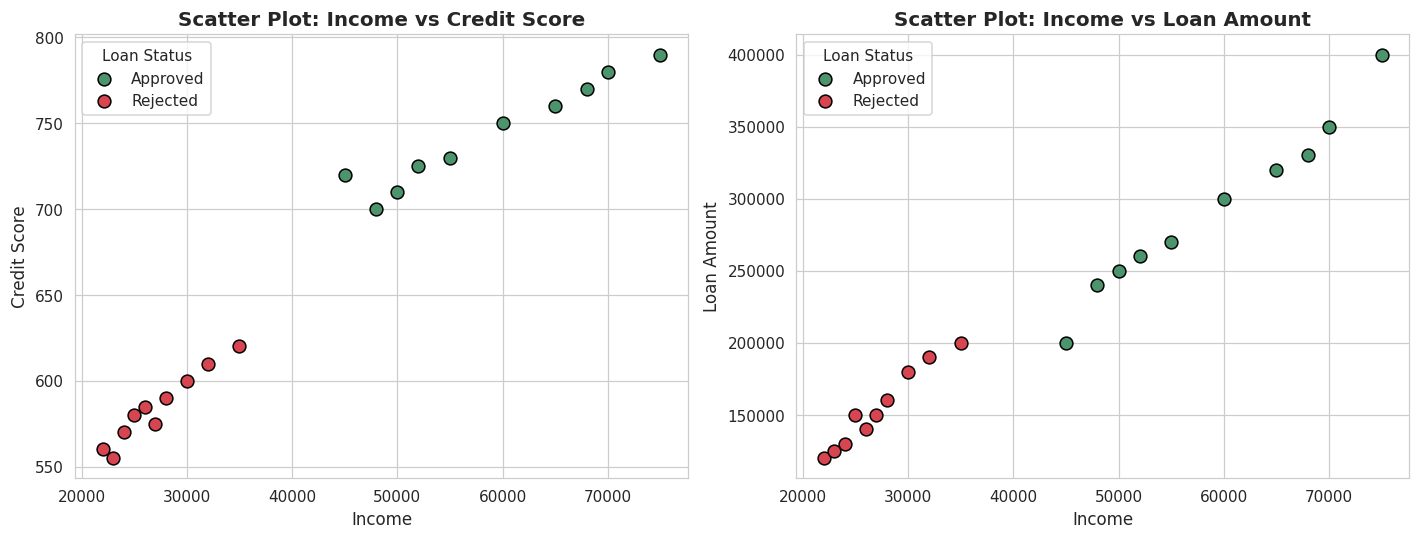

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for status, c in colors_status.items():
    subset = df[df['Loan_Status'] == status]
    axes[0].scatter(subset['Income'], subset['Credit_Score'], label=status,
                     color=c, edgecolor='black', s=70)
    axes[1].scatter(subset['Income'], subset['Loan_Amount'], label=status,
                     color=c, edgecolor='black', s=70)

axes[0].set_title('Scatter Plot: Income vs Credit Score')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Credit Score')
axes[0].legend(title='Loan Status')

axes[1].set_title('Scatter Plot: Income vs Loan Amount')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Loan Amount')
axes[1].legend(title='Loan Status')

plt.tight_layout()
plt.show()


**Observation:** Approved (green) and Rejected (red) applicants form two completely separate clusters in both scatter plots — there is a clear gap between the two groups rather than a gradual, overlapping transition.

## Task 5d: Line Chart — Trend Analysis (Bonus Visualization)

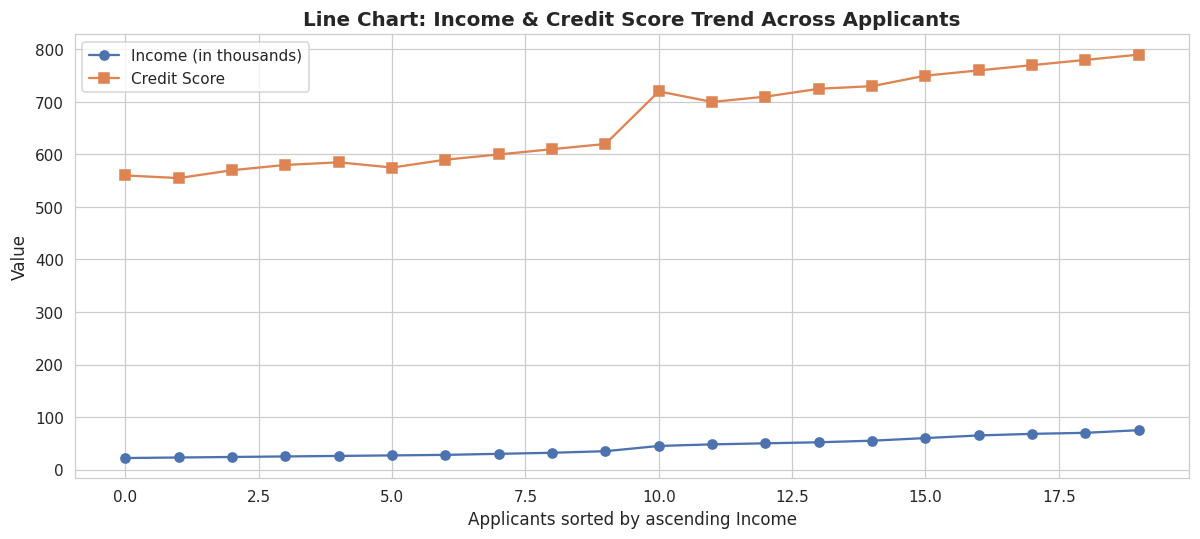

In [20]:
trend_df = df.sort_values('Income').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(trend_df.index, trend_df['Income']/1000, marker='o', color='#4C72B0', label='Income (in thousands)')
ax1.plot(trend_df.index, trend_df['Credit_Score'], marker='s', color='#DD8452', label='Credit Score')
ax1.set_xlabel('Applicants sorted by ascending Income')
ax1.set_ylabel('Value')
ax1.set_title('Line Chart: Income & Credit Score Trend Across Applicants')
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** When applicants are sorted by income, credit score rises almost in lock-step — the two variables move together very tightly, reinforcing what the correlation analysis below will show.

## Task 6c: Important Patterns — Correlation Heatmap

In [21]:
df_corr = df.copy()
df_corr['Status_Num'] = (df_corr['Loan_Status'] == 'Approved').astype(int)
corr_matrix = df_corr[num_cols + ['Status_Num']].corr().round(2)
show_df(corr_matrix)


,Income,Credit_Score,Loan_Amount,Status_Num
Income,1.00,0.98,0.99,0.90
Credit_Score,0.98,1.00,0.95,0.95
Loan_Amount,0.99,0.95,1.00,0.84
Status_Num,0.90,0.95,0.84,1.00


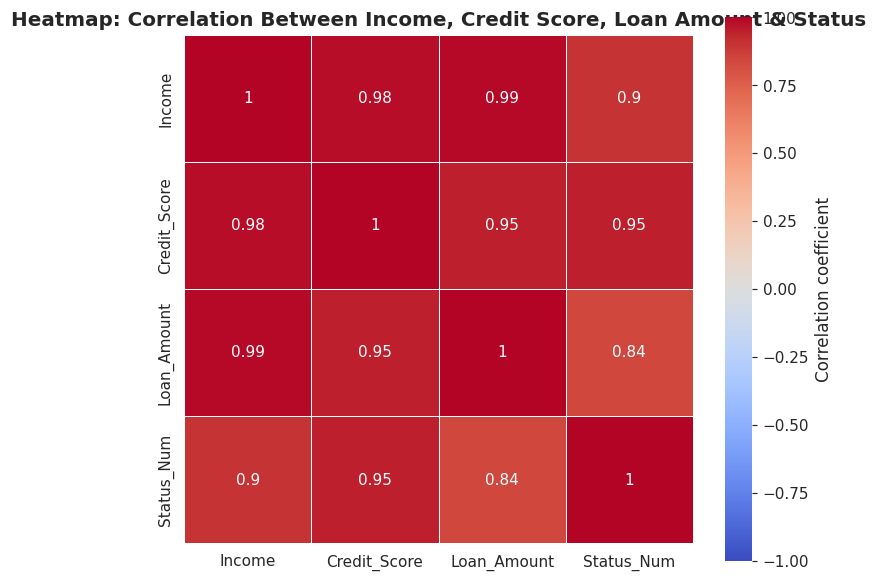

In [22]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation coefficient'}, ax=ax)
ax.set_title('Heatmap: Correlation Between Income, Credit Score, Loan Amount & Status')
plt.tight_layout()
plt.show()


**Observation:** `Income`, `Credit_Score`, `Loan_Amount` and `Status_Num`
are all **very strongly positively correlated** with each other
(coefficients close to 1). This confirms that in this sample, income and
credit score do not vary independently of employment type or approval —
they move together almost perfectly.


## Task 7: Observations (4–5 Key Observations)

1. **Dataset is clean**: no missing values, no duplicate records, and all
   values fall within logical/industry-standard ranges.
2. **Balanced target**: exactly 50% Approved and 50% Rejected.
3. **Employment_Type perfectly predicts Loan_Status** in this sample —
   all 10 Salaried applicants were Approved, and all 10 Self-employed +
   Unemployed applicants were Rejected, with zero exceptions.
4. **Income and Credit_Score also perfectly separate** the Approved and
   Rejected groups, with no overlap between the two groups' ranges.
5. All three numeric predictors are very strongly correlated with each
   other and with approval status, so their individual effects cannot be
   separated from this data alone.

## Task 8: Conclusion

In this sample, employment type, income, and credit score are fully
confounded and together explain loan approval almost perfectly. Before
relying on employment type as an approval rule in practice, the bank
should audit whether it is over-relying on this single factor and
collect more varied examples (e.g. high-income self-employed applicants)
to test each factor's independent effect — both to build a more robust
underwriting model and to avoid unfairly excluding creditworthy
applicants.
